In [6]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
# Load Dataset
df = pd.read_csv('social_media.csv')

In [10]:
# Inspect dataset
df.head()
df.info()
df.describe().round(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0
mean,21.0,5.0,171.0,3.0,2.0,7.0,6.0
std,2.0,2.0,43.0,2.0,1.0,1.0,1.0
min,18.0,1.0,62.0,0.0,-0.0,4.0,4.0
25%,19.0,4.0,140.0,2.0,1.0,6.0,5.0
50%,21.0,5.0,171.0,3.0,2.0,7.0,6.0
75%,22.0,6.0,204.0,4.0,2.0,8.0,7.0
max,24.0,9.0,273.0,8.0,4.0,10.0,9.0


In [11]:
# Check if there are NAs - No NAS
df.isnull().sum()

# check if there are duplicates - there are two duplicates
df.duplicated().sum()

# Remove duplicates
df = df.drop_duplicates()
# Check if duplicates are removed. 
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4998 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4998 non-null   int64  
 1   Gender                   4998 non-null   object 
 2   Country                  4998 non-null   object 
 3   Academic_Level           4998 non-null   object 
 4   Most_Used_Platform       4998 non-null   object 
 5   Purpose_Of_Use           4998 non-null   object 
 6   Avg_Daily_Usage_Hours    4998 non-null   float64
 7   Daily_Unlocks            4998 non-null   int64  
 8   Study_Hours              4998 non-null   float64
 9   Physical_Activity_Hours  4998 non-null   float64
 10  Sleep_Hours_Per_Night    4998 non-null   float64
 11  Stress_Level             4998 non-null   object 
 12  Mental_Health_Score      4998 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 546.7+ KB


In [12]:

# Check for outliers
# -- physycal activity hours contain negative values: Remove all of them 	
df.describe()

# remove negative illogical variables
df = df[df['Physical_Activity_Hours'] > 0] 

# Check if it looks OK
df.describe()

# Looks ok

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4975.000000,4975.000000,4975.000000,4975.000000,4975.000000,4975.000000,4975.000000
mean,20.823116,5.068503,171.187136,3.014995,1.759256,6.640503,6.238010
std,1.736476,1.650450,42.763196,1.637066,0.658087,1.220383,1.276456
min,18.000000,1.000000,62.000000,0.300000,0.100000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.700000,5.100000
50%,21.000000,5.000000,171.000000,2.900000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,203.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


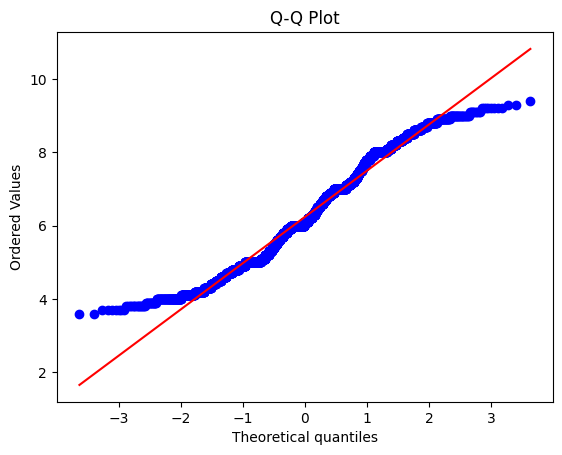

In [13]:
import scipy.stats as stats
stats.probplot(df["Mental_Health_Score"], dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

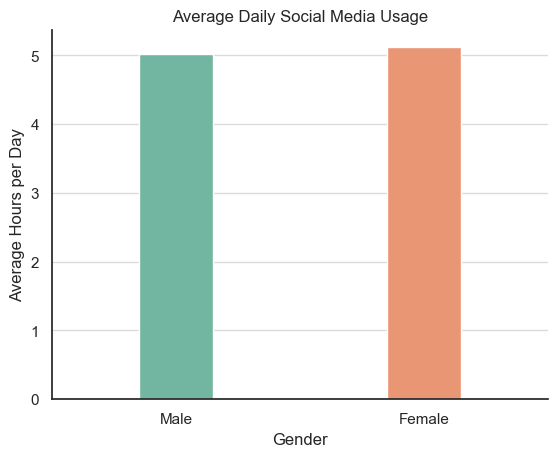

In [14]:

sns.set_theme(style = 'white')

# Plot Gender differences in Daily Usage of Social Media 
#df.groupby('Gender')['Avg_Daily_Usage_Hours'].mean()
sns.barplot(
    data=df, 
    x='Gender', 
    y='Avg_Daily_Usage_Hours',  # Calcualtes mean automatically 
    errorbar = None,
    palette = 'Set2', # Old method
    hue = "Gender",
    legend = False, 
    width = .3
)

#Remove the top and right borders of the black box
sns.despine()
# Add title and label
plt.title('Average Daily Social Media Usage'),
plt.ylabel("Average Hours per Day")


# Put Gridlines
plt.gca().set_axisbelow(True)  # Puts gridlines behind the bars
plt.grid(axis="y", linestyle="-", alpha=0.7)

# Shrink Column width 



plt.show()

In [16]:
# do regression with statsmodel 
import statsmodels.api as sm


# define variable
y = df["Mental_Health_Score"] # Dependent Variable
X = df[["Avg_Daily_Usage_Hours", "Physical_Activity_Hours", "Sleep_Hours_Per_Night", "Study_Hours"]] #Independent variable

X = sm.add_constant(X)


#Fit model
ols_model = sm.OLS(y, X).fit()

# 5. Display the summary table
print(ols_model.summary())


                             OLS Regression Results                            
Dep. Variable:     Mental_Health_Score   R-squared:                       0.702
Model:                             OLS   Adj. R-squared:                  0.702
Method:                  Least Squares   F-statistic:                     2925.
Date:                 Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                         12:37:57   Log-Likelihood:                -5262.7
No. Observations:                 4975   AIC:                         1.054e+04
Df Residuals:                     4970   BIC:                         1.057e+04
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const           

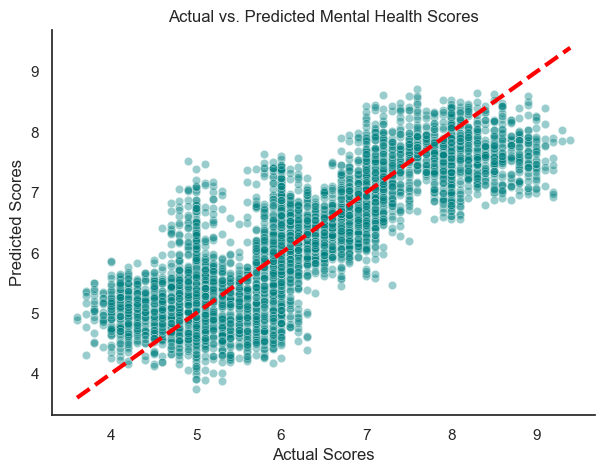

In [17]:
# Make prediction
y_pred = ols_model.predict(X)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y, y=y_pred, alpha=0.4, color="teal")

# Add the perfect-fit diagonal line
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--", lw=3)

plt.title("Actual vs. Predicted Mental Health Scores")
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
sns.despine()
plt.show()

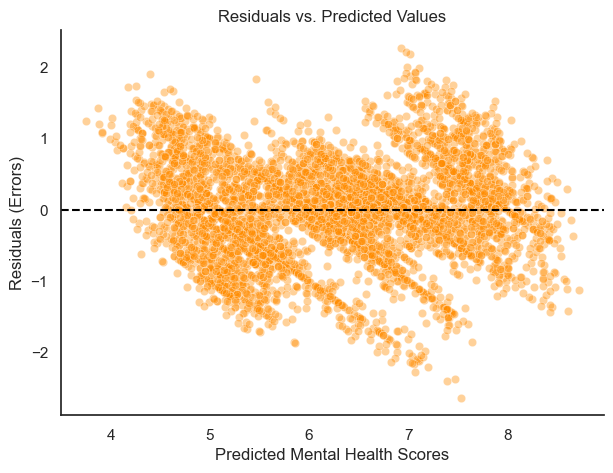

In [18]:
# check model for homoscedasticity 

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_pred, y=ols_model.resid, alpha=0.4, color="darkorange")
plt.axhline(y=0, color="black", linestyle="--", lw=1.5)

plt.title("Residuals vs. Predicted Values")
plt.xlabel("Predicted Mental Health Scores")
plt.ylabel("Residuals (Errors)")
sns.despine()
plt.show()

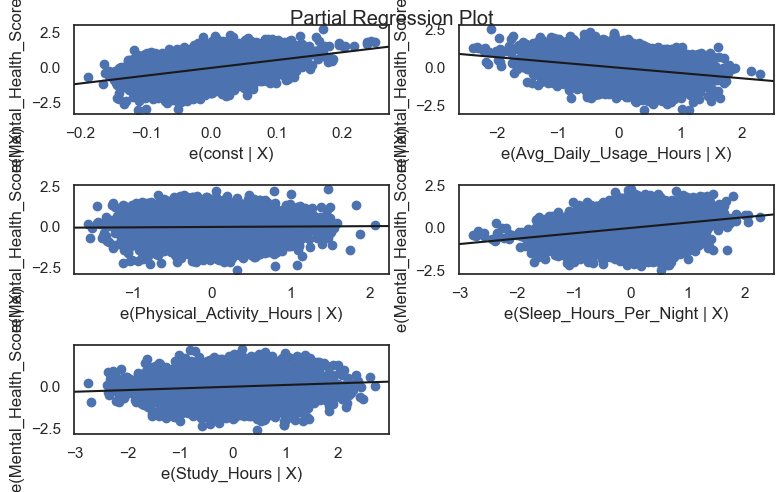

In [19]:
fig = plt.figure(figsize=(8, 5))

# This built-in statsmodels function creates partial plots for all variables
sm.graphics.plot_partregress_grid(ols_model, fig=fig)
plt.show()

# **Model Summery and Insights**

1. Results show that approximately 70% of the variance in student mental health scores is explained by the habits tracked in this study.
2. Holding all other variables constant, every additional hour a student spends on social media per day drops their predicted mental health score by 0.43 points.
3. Each extra hour of sleep per night is associated with a 0.32-point increase in the student's mental health score, making sleep a crucial protective factor.
4. Physical activity hours do not have a statistically significant relationship with the mental health score.